In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage


from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

plt.figure(dpi=500)
from warnings import filterwarnings
filterwarnings('ignore')

<Figure size 3200x2400 with 0 Axes>

# 2. Data Exploration

In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/bank-marketing-data.csv')
print(f"Shape of Data :{df.shape}")

Shape of Data :(8950, 18)


In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.sample(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
1498,C11549,2619.752921,1.000000,3563.07,2675.63,887.44,0.000000,0.916667,0.666667,0.666667,0.000000,0,69,4500.0,1227.952887,688.645056,0.0,12
714,C10741,821.916526,0.857143,1386.40,1386.40,0.00,0.000000,0.285714,0.285714,0.000000,0.000000,0,3,1500.0,238.348011,154.555561,0.0,7
6331,C16506,829.410423,1.000000,3884.68,2610.57,1274.11,0.000000,1.000000,1.000000,1.000000,0.000000,0,84,8000.0,3517.817878,200.202740,0.0,12
5926,C16092,1700.753811,1.000000,0.00,0.00,0.00,624.480873,0.000000,0.000000,0.000000,0.500000,9,0,2000.0,418.596666,434.688783,0.0,12
1864,C11926,4379.015578,1.000000,996.64,860.50,136.14,3632.137219,0.916667,0.666667,0.416667,0.333333,4,27,14500.0,2034.929239,1064.251367,0.0,12


In [6]:
df = df.set_index("CUST_ID")

In [7]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 2.1 Data Summary

In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## 2.2 Data info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8950 entries, C10001 to C19190
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CRED

# 2.3 Missing values check

In [10]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


- There are 313 missing values 8950 observation in `MINIMUM_PAYMENTS`
- 1 missing value in the `CREDIT_LIMIT`

## 2.4 Duplicates Check

In [11]:
df.duplicated().any()

False

No duplicates in the data

## 2.5 MINIMUM_PAYMENTS

Generating descriptive statistics for the subset of rows in the DataFrame df where the MINIMUM_PAYMENTS column has missing values.

In [12]:
df[df["MINIMUM_PAYMENTS"].isnull()].describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,0.0,313.0,313.000000
mean,555.441321,0.389403,393.087284,250.433387,142.653898,559.136698,0.336043,0.107886,0.244670,0.067169,1.460064,5.833866,3731.789137,322.286168,NaN,0.0,11.063898
std,1292.687887,0.408341,757.905701,624.453991,311.289043,1185.132567,0.372517,0.227370,0.359756,0.130087,3.182359,9.600908,2924.606153,1996.658905,NaN,0.0,1.869734
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000,NaN,0.0,6.000000
25%,0.187069,0.090909,1.400000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1500.000000,0.000000,NaN,0.0,12.000000
50%,16.848358,0.181818,130.400000,0.000000,0.000000,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,2.000000,3000.000000,0.000000,NaN,0.0,12.000000
75%,286.686616,1.000000,399.950000,176.030000,152.280000,480.104401,0.583333,0.083333,0.416667,0.083333,1.000000,8.000000,5000.000000,0.000000,NaN,0.0,12.000000
max,9164.724752,1.000000,7597.090000,6761.290000,2959.240000,7616.064965,1.000000,1.000000,1.000000,1.000000,21.000000,77.000000,19500.000000,29272.486070,NaN,0.0,12.000000


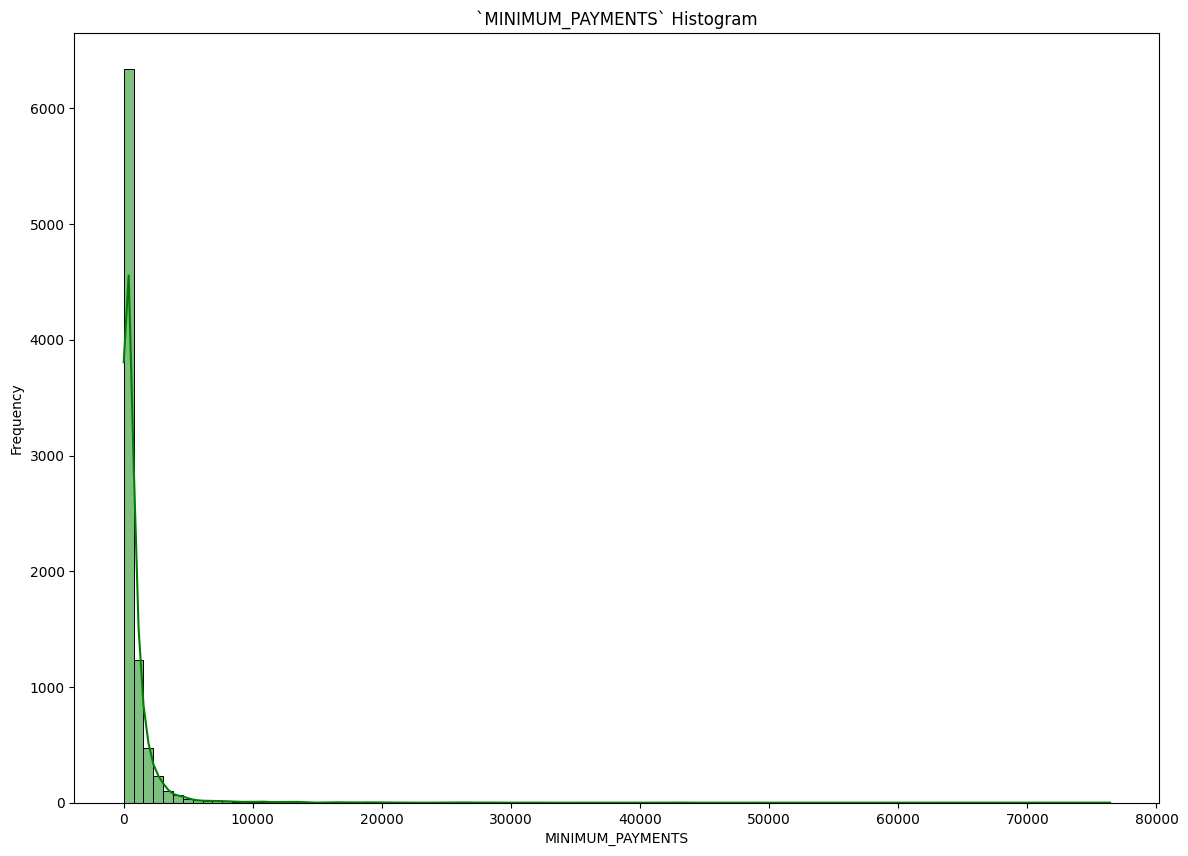

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.histplot(df['MINIMUM_PAYMENTS'], bins=100, alpha=0.5, color='g', kde=True)
plt.title('`MINIMUM_PAYMENTS` Histogram')
plt.xlabel('MINIMUM_PAYMENTS')
plt.ylabel('Frequency')
plt.show()

The data in MINIMUM_PAYMENTS is right-skewed and there are missing values, we can consider filling the missing values with the minimum non-zero value of the column to  avoid inflating the central tendency,

### 2.5.1 Imputing Missing Value


In [14]:
min_value = df['MINIMUM_PAYMENTS'].min()
df['MINIMUM_PAYMENTS'].fillna(min_value, inplace=True)

print("No of missing values in `MINIMUM_PAYMENTS` : ", df["MINIMUM_PAYMENTS"].isnull().sum())

No of missing values in `MINIMUM_PAYMENTS` :  0


## 2.6. CREDIT_LIMIT

In [15]:
print("No of missing values in `CREDIT_LIMIT` : ", df["CREDIT_LIMIT"].isnull().sum())


No of missing values in `CREDIT_LIMIT` :  1


- There is only 1 value in the `CREDIT_LIMIT` out 0f 8950 observation. We can simply remove this observation from the data.

In [16]:
df = df.dropna(subset=['CREDIT_LIMIT'], axis=0)

print("No of missing values in `CREDIT_LIMIT` : ", df["CREDIT_LIMIT"].isnull().sum())
print(f"Shape of Data :{df.shape}")

No of missing values in `CREDIT_LIMIT` :  0
Shape of Data :(8949, 17)


# 2.7. Correlation

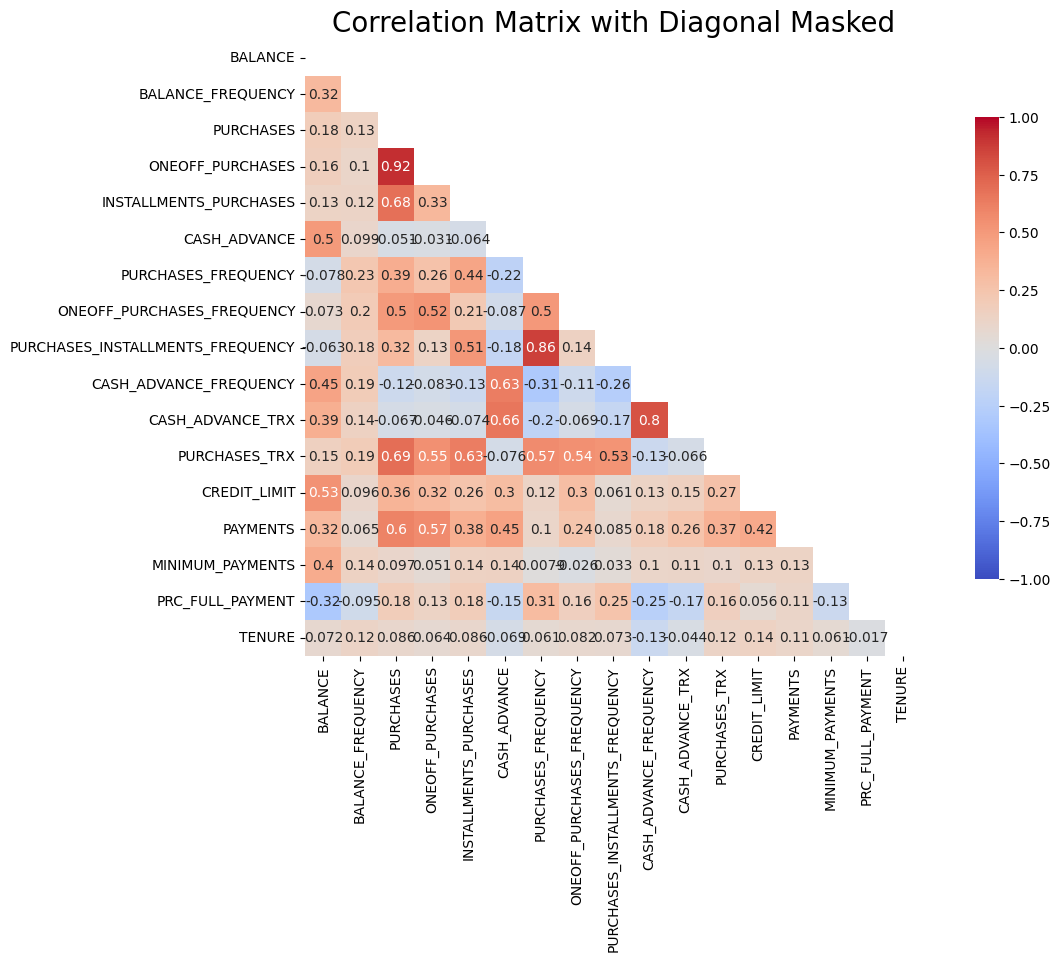

In [17]:
plt.figure(figsize=(14, 8))

mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', mask=mask, square=True, cbar_kws={"shrink": 0.75}, vmin=-1, vmax=1)


plt.title("Correlation Matrix with Diagonal Masked", fontsize=20)
plt.show()

### Strong Positive Correlations:
- **Oneoff_Purchases with Purchases (0.92)**: Higher one-off purchases strongly relate to higher total purchases.
- **Cash_Advance with Cash_Advance_TRX (0.80)**: More cash advance transactions mean a higher cash advance amount.

### Notable Negative Correlations:
- **PRC_Full_Payment with Balance (-0.32)**: Higher likelihood of full payments associates with lower balances.
- **PRC_Full_Payment with Cash_Advance (-0.30)**: More full payments correlate with less reliance on cash advances.

### Moderate Correlations:
- **Balance with Cash_Advance (0.50)**: Higher balances tend to coincide with higher cash advances.
- **Credit_Limit with Cash_Advance (0.36)**: Larger credit limits slightly relate to higher cash advance amounts.

### Low Correlations:
- **Most other pairs** show weak or no significant relationships, indicating limited interaction among those variables.


df

# 3. Analysis

# 3.1 PCA

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

In [19]:
pca = PCA()
X_pca = pca.fit_transform(df_scaled)

pca_columns = [f'PCA{i+1}' for i in range((len(df.columns)))]
pca_df = pd.DataFrame(data=X_pca, columns=pca_columns)
pca_df.head()

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,PCA11,PCA12,PCA13,PCA14,PCA15,PCA16,PCA17
0,-1.684484,-1.070217,-0.469997,0.686725,-0.056053,-0.080315,-0.817358,-0.006871,0.119547,0.078525,-0.236376,0.051641,0.082369,0.188378,-0.149238,0.048147,0.000160
1,-1.132568,2.510222,-0.603830,-0.104391,-0.701246,1.074137,0.391847,0.196580,0.667960,0.778227,-0.870268,0.610110,0.033135,0.731434,0.533417,-0.082876,-0.000003
2,0.968926,-0.383446,-0.086175,1.252350,2.160177,0.394581,1.522617,-0.258764,-0.859574,0.001632,-0.762395,-0.683279,-0.697248,-0.042265,-0.221157,0.511270,-0.000023
3,-0.897248,-0.017764,-1.526942,1.031341,-0.189525,0.198574,0.210129,-0.761288,-0.014698,-0.393904,0.748709,-0.101937,0.112596,0.413100,0.084170,-0.014561,0.000013
4,-1.600519,-0.681375,-0.340010,1.024973,0.436712,-0.078247,-0.691393,0.263664,0.575308,0.122481,-0.455140,0.110116,0.036774,0.041101,-0.291180,-0.070558,0.000081


In [20]:
explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_


pca_summary = pd.DataFrame({
    'Eigenvalues': eigenvalues,
    'Explained Variance': explained_var,
    'Cumulative Explained Variance': cumulative_var,
})

pca_summary.index = pd.RangeIndex(start=1, stop=len(explained_var) + 1, name='Principal Component')

pca_summary

,Eigenvalues,Explained Variance,Cumulative Explained Variance
Principal Component,,,
1,4.641399,2.729930e-01,0.272993
2,3.454852,2.032039e-01,0.476197
3,1.500345,8.824573e-02,0.564443
4,1.271731,7.479937e-02,0.639242
5,1.054981,6.205077e-02,0.701293
6,0.974672,5.732724e-02,0.758620
7,0.830031,4.881988e-02,0.807440
8,0.735091,4.323579e-02,0.850676
9,0.642875,3.781196e-02,0.888488


In [21]:
def get_img_path(img_name):
    file_path = os.path.join("..", "imgs", img_name)
    return file_path

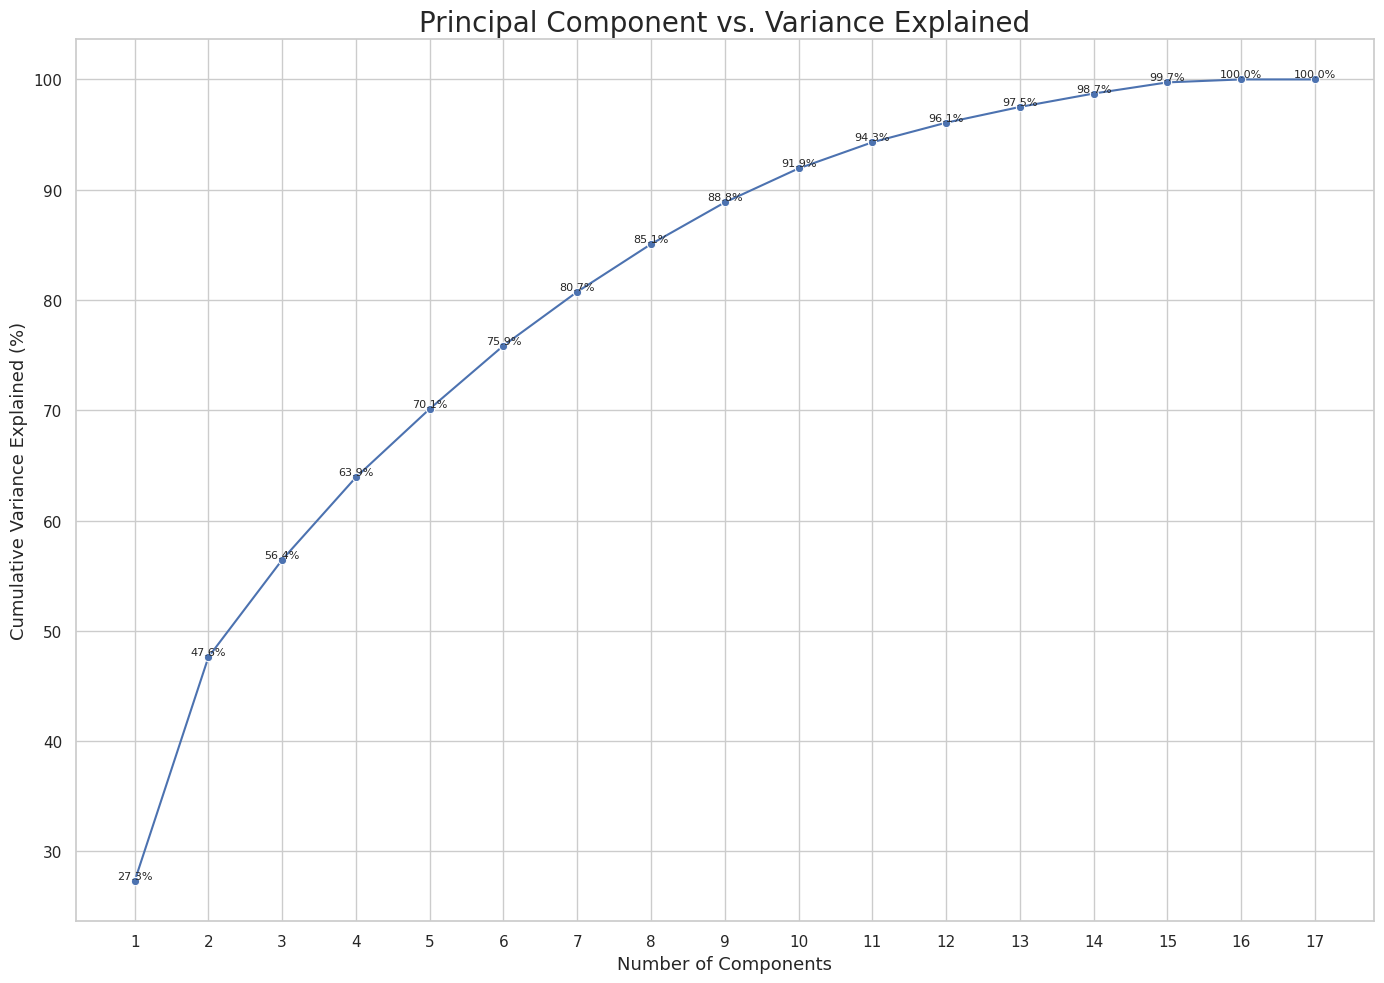

Image saved at: /content/pca_variance_explained.png


In [22]:
# Configure the plot style
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")  # A clean, minimal style is suitable for Colab visuals

# Plot cumulative explained variance
sns.lineplot(x=np.arange(1, len(pca.explained_variance_ratio_) + 1),
             y=np.cumsum(pca.explained_variance_ratio_) * 100, marker='o', color="b")

# Annotate each point with the cumulative variance percentage
for i, percentage in enumerate(np.cumsum(pca.explained_variance_ratio_) * 100):
    plt.text(i + 1, percentage, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=8)

# Labels and title
plt.xlabel('Number of Components', fontsize=13)
plt.ylabel('Cumulative Variance Explained (%)', fontsize=13)
plt.title('Principal Component vs. Variance Explained', fontsize=20)
plt.xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1))

# Save the plot as a high-resolution image in Colab
plt.tight_layout()
img_path = "/content/pca_variance_explained.png"
plt.savefig(img_path, dpi=700)
plt.show()

# Display the saved image path for download if needed
print(f"Image saved at: {img_path}")


# 3.2. K-Means Clustering

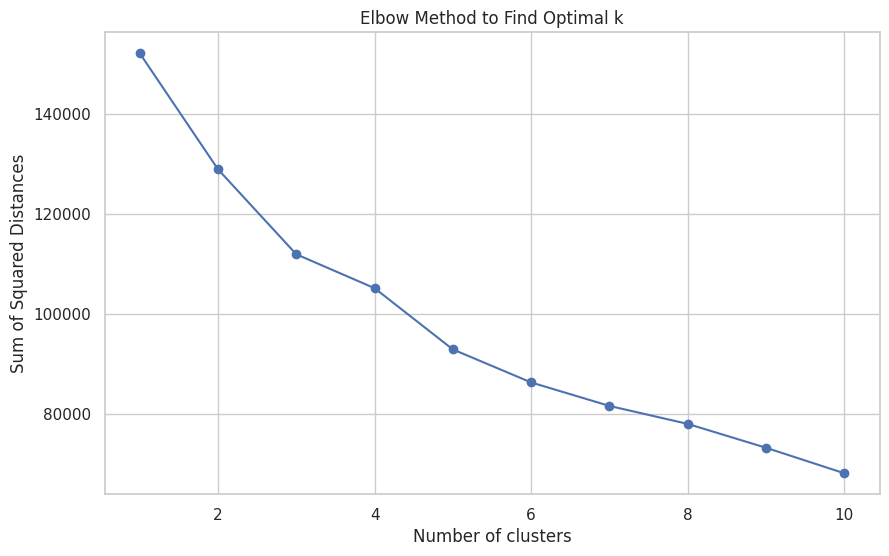

In [23]:
# List to store the sum of squared distances
sse = []

# Test clustering with 1 to 10 clusters
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Sum of Squared Distances")
plt.title("Elbow Method to Find Optimal k")
plt.show()


we can take k = 4 or 5

## 3.2.1. Silhouette score for choosing between k= 4 and. k = 5

In [24]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Define models for 4 and 5 clusters
kmeans_4 = KMeans(n_clusters=4, random_state=42)
kmeans_5 = KMeans(n_clusters=5, random_state=42)

# Fit the models and predict clusters
labels_4 = kmeans_4.fit_predict(df_scaled)
labels_5 = kmeans_5.fit_predict(df_scaled)

# Calculate silhouette scores
silhouette_score_4 = silhouette_score(df_scaled, labels_4)
silhouette_score_5 = silhouette_score(df_scaled, labels_5)

print(f"Silhouette Score for 4 Clusters: {silhouette_score_4}")
print(f"Silhouette Score for 5 Clusters: {silhouette_score_5}")


Silhouette Score for 4 Clusters: 0.2241573918853967
Silhouette Score for 5 Clusters: 0.20996715451096024


- 4 Clusters: 0.22415
- 5 Clusters: 0.2099

The silhouette score is slightly higher for 4 clusters than for 5 clusters, indicating that the 4-cluster solution provides slightly better-defined clusters in terms of separation and cohesion.

# 3.2.2.  4 clusters

In [25]:
kmeans= KMeans(4, random_state = 0)
kmeans.fit(df_scaled)
labels=kmeans.labels_

inertia = kmeans.inertia_
n_iter = kmeans.n_iter_
n_features_in = kmeans.n_features_in_

print(f"\nSum of Squared Distances to Closest Cluster Center (Inertia): {inertia:.1f}")
print("\nNumber of Iterations Run: ", n_iter)
print("\nNumber of Features Seen During Fit:", n_features_in)


Sum of Squared Distances to Closest Cluster Center (Inertia): 99048.3

Number of Iterations Run:  17

Number of Features Seen During Fit: 17


In [26]:
clusters_df = df.copy()
clusters_df['cluster_label'] = labels
clusters_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_label
CUST_ID,,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.019163,0.000000,12,1
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


Here, We are visualizing clusters created by the KMeans algorithm on data that has been reduced to two principal components (PCA1 and PCA2). Each point in the scatter plot represents an observation from the dataset, and each cluster is shown in a distinct color. This visualization helps us:

By plotting clusters along two principal components, we can visually assess how well-separated the clusters are in reduced dimensional space.

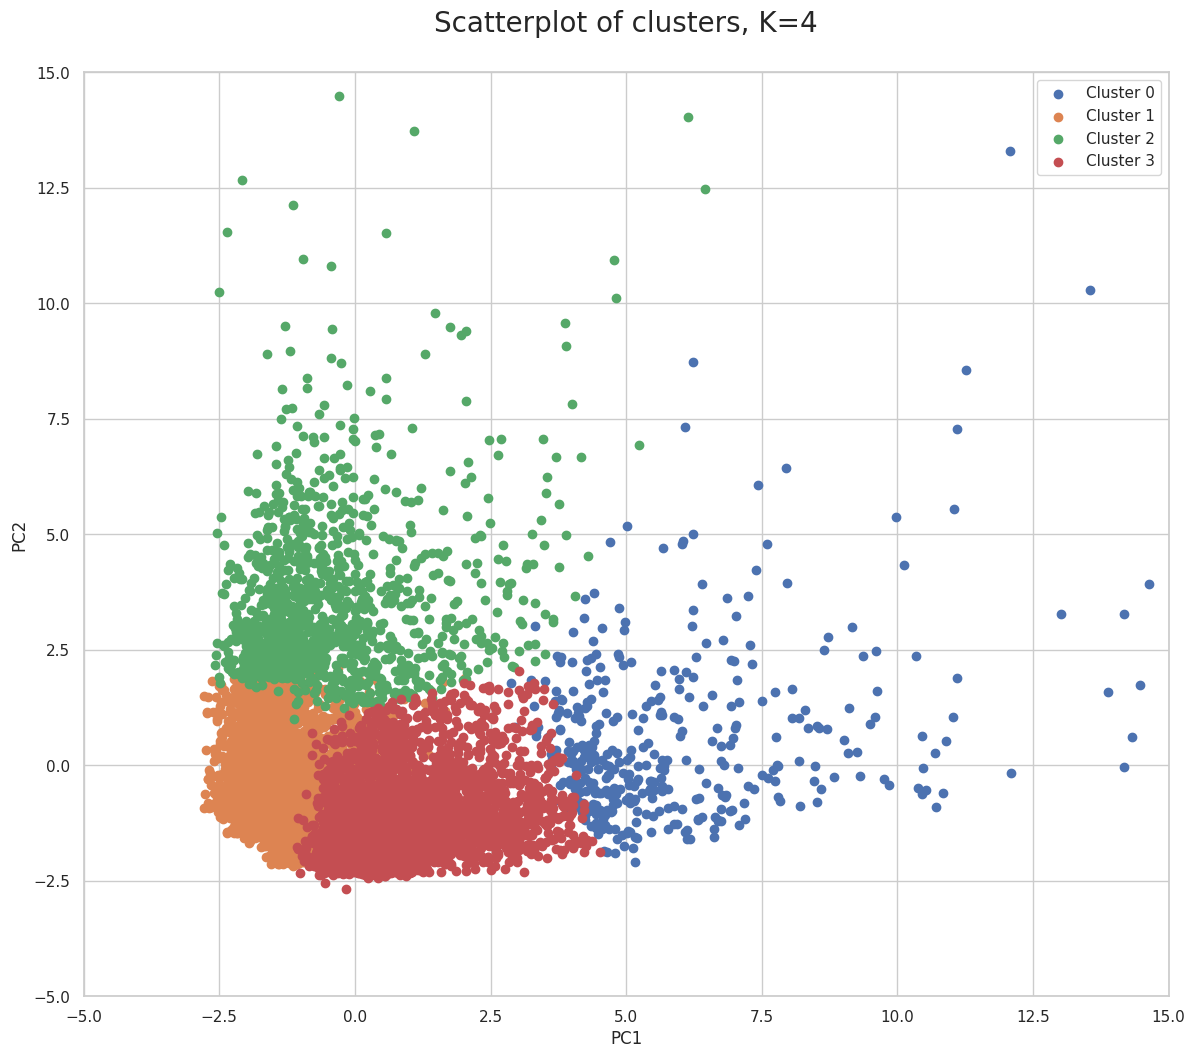

In [27]:
plt.figure(figsize=(14, 12))

clusters_df = pca_df[['PCA1', 'PCA2']]
clusters_df['cluster_label'] = labels
for cluster_name, cluster_data in clusters_df.groupby('cluster_label'):
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster_name}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatterplot of clusters, K=4\n', fontsize = 20)
plt.xlim(-5, 15)
plt.ylim(-5, 15)
plt.legend()
plt.show()




- **Cluster Separation:** The four clusters are generally well-separated, with Cluster 0 (blue) distinctly isolated on the left, while Clusters 1 (red) and 2 (green) overlap slightly, suggesting some similarity.

- **Density and Spread:** Cluster 3 (orange) is compact, indicating tightly grouped data points, while Clusters 1 and 2 cover more area, showing greater spread.

- **Principal Components:** The plot confirms that PC1 and PC2 capture significant data variation, effectively differentiating the clusters.

# 3.2.3. Biplot

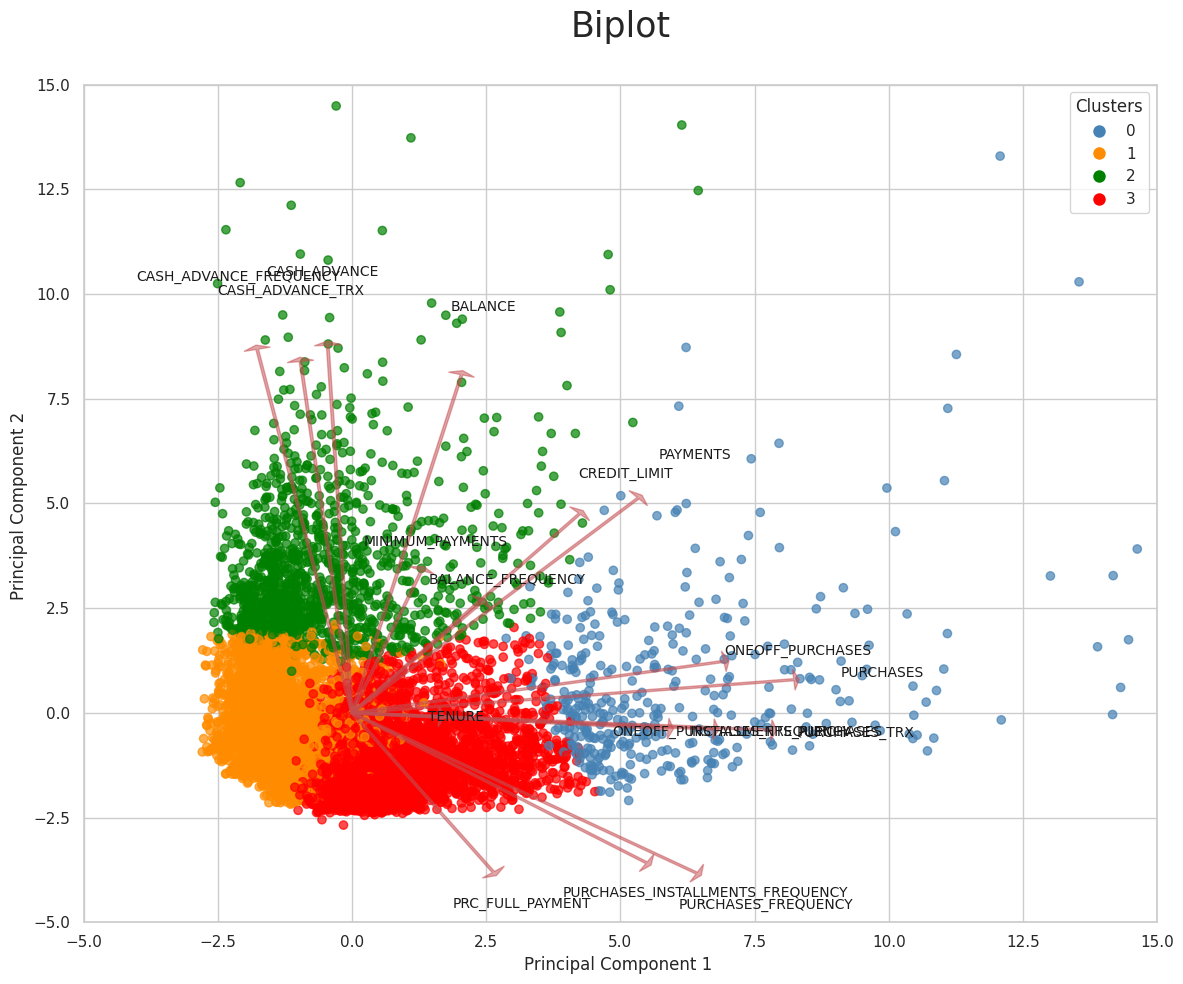

In [28]:
pca_result = pca.fit_transform(df_scaled)

def biplot(score, coeff, labels=None, scaling_factor=1.0):
    plt.figure(figsize=(12, 10))
    coeff = np.transpose(coeff)

    custom_cmap = {0: 'steelblue', 1: 'darkorange', 2: 'green', 3: 'red'}
    cluster_colors = clusters_df['cluster_label'].map(custom_cmap)
    plt.scatter(score[:, 0], score[:, 1], alpha=0.7, c=cluster_colors)

    for i in range(coeff.shape[1]):
        plt.arrow(0, 0, coeff[0, i] * scaling_factor, coeff[1, i] * scaling_factor,
                  color='r', alpha=0.5, head_width=0.5, head_length=0.1,width = 0.05)
        if labels is not None:
            plt.text(coeff[0, i] * scaling_factor * 1.2, coeff[1, i] * scaling_factor * 1.2,
                     labels[i], color='k', ha='center', va='center',fontsize = 10)

    plt.xlabel(f'Principal Component 1 ')
    plt.ylabel(f'Principal Component 2 ')
    plt.title('Biplot\n', fontsize = 25)

    legend_handles = []
    for label, color in custom_cmap.items():
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'{label}', markerfacecolor=color, markersize=10))
    plt.legend(handles=legend_handles, title='Clusters', loc='best')

    plt.xlim(-5, 15)
    plt.ylim(-5, 15)

    img_path = get_img_path("biplot.png")
    plt.tight_layout()

    plt.show()

biplot(pca_result, np.transpose(pca.components_), labels=df.columns, scaling_factor=20.0)

- **Feature Vectors (Arrows):**
CASH_ADVANCE, CASH_ADVANCE_TRX, FREQUENCY: Strongly aligned with PC2 and Cluster 2 (green), indicating high cash advance usage and frequency.

- **TENURE, PRC_FULL_PAYMENT:** Point towards Cluster 3 (red), suggesting this group includes customers with long tenure and consistent full payments.

- **ONEOFF_PURCHASES, PURCHASES, PURCHASES_FREQUENCY:** Aligned with PC1 and Cluster 0 (blue), indicating frequent purchase behaviors.
BALANCE, CREDIT_LIMIT, MINIMUM_PAYMENTS: Associated with Cluster 2 (green), indicating higher balances and credit limits.

- **Cluster Characteristics:**

    ***Blue Cluster (Cluster 0):*** Represents frequent purchasers with high transaction activity.

    ***Green Cluster (Cluster 2):*** Defined by high balances, credit limits, and cash advances.

    ***Red Cluster (Cluster 3):*** Represents loyal, long-tenure customers with consistent payments.

    ***Orange Cluster (Cluster 1):*** Likely lower credit activity or engagement.


# 3.3. K-Means on PCA

From section 3.1, we have observed that the first 10 principal components explain approximately 92% of the variance.

In [29]:
pc10_df = pca_df.iloc[:, :10]
pc10_df

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10
0,-1.684484,-1.070217,-0.469997,0.686725,-0.056053,-0.080315,-0.817358,-0.006871,0.119547,0.078525
1,-1.132568,2.510222,-0.603830,-0.104391,-0.701246,1.074137,0.391847,0.196580,0.667960,0.778227
2,0.968926,-0.383446,-0.086175,1.252350,2.160177,0.394581,1.522617,-0.258764,-0.859574,0.001632
3,-0.897248,-0.017764,-1.526942,1.031341,-0.189525,0.198574,0.210129,-0.761288,-0.014698,-0.393904
4,-1.600519,-0.681375,-0.340010,1.024973,0.436712,-0.078247,-0.691393,0.263664,0.575308,0.122481
...,...,...,...,...,...,...,...,...,...,...
8944,-0.363616,-2.011357,0.972365,-2.751539,-0.025599,-2.675851,1.584835,0.300969,1.338295,0.843490
8945,-0.590114,-1.696259,1.188659,-2.046311,0.239421,-3.267281,1.058988,-0.700933,0.967791,1.243780
8946,-0.929900,-1.806109,0.456199,-2.306577,-0.128611,-2.984803,1.422893,-0.278665,0.785603,0.828470
8947,-2.338056,-0.650937,-0.980592,-1.844275,0.171597,-3.185369,1.000218,0.259497,1.172735,-0.270258


Here, we are attempting to determine the optimal number of clusters. Instead of fitting K-means on the entire dataset, we are applying it to the first 10 principal components, as they capture a significant amount of variance, which helps reduce computational cost. We then use the elbow method to identify the optimal number of clusters.

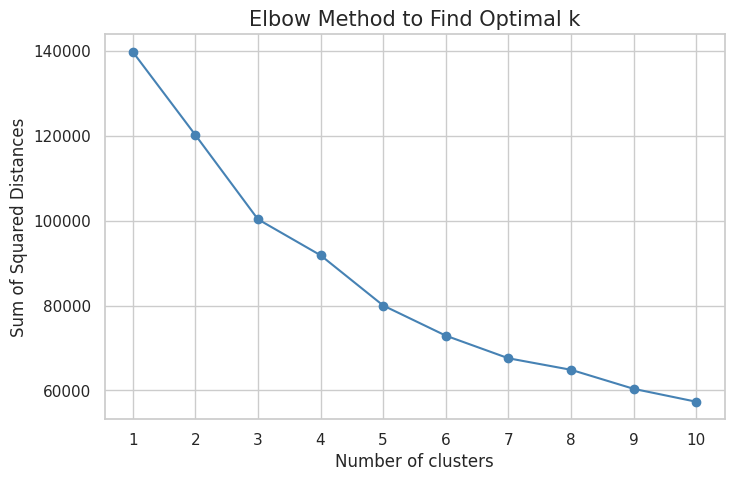

In [30]:
n_clusters = 10
cost = []

# Loop through the range of clusters and compute the cost (inertia)
for i in range(1, n_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pc10_df)
    cost.append(kmeans.inertia_)

# Plot the elbow plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_clusters + 1), cost, marker='o', linestyle='-', color='steelblue')
plt.title('Elbow Method to Find Optimal k', fontsize=15)
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Sum of Squared Distances', fontsize=12)
plt.xticks(range(1, n_clusters + 1))  # Setting x-ticks to display each cluster number
plt.grid(True)
plt.show()


optimal number of cluster is 4

In [31]:
kmeans= KMeans(4, random_state = 0)
kmeans.fit(df_scaled)
labels=kmeans.labels_

inertia = kmeans.inertia_
n_iter = kmeans.n_iter_
n_features_in = kmeans.n_features_in_

print(f"\nSum of Squared Distances to Closest Cluster Center (Inertia): {inertia:.1f}")
print("\nNumber of Iterations Run: ", n_iter)
print("\nNumber of Features Seen During Fit:", n_features_in)


Sum of Squared Distances to Closest Cluster Center (Inertia): 99048.3

Number of Iterations Run:  17

Number of Features Seen During Fit: 17


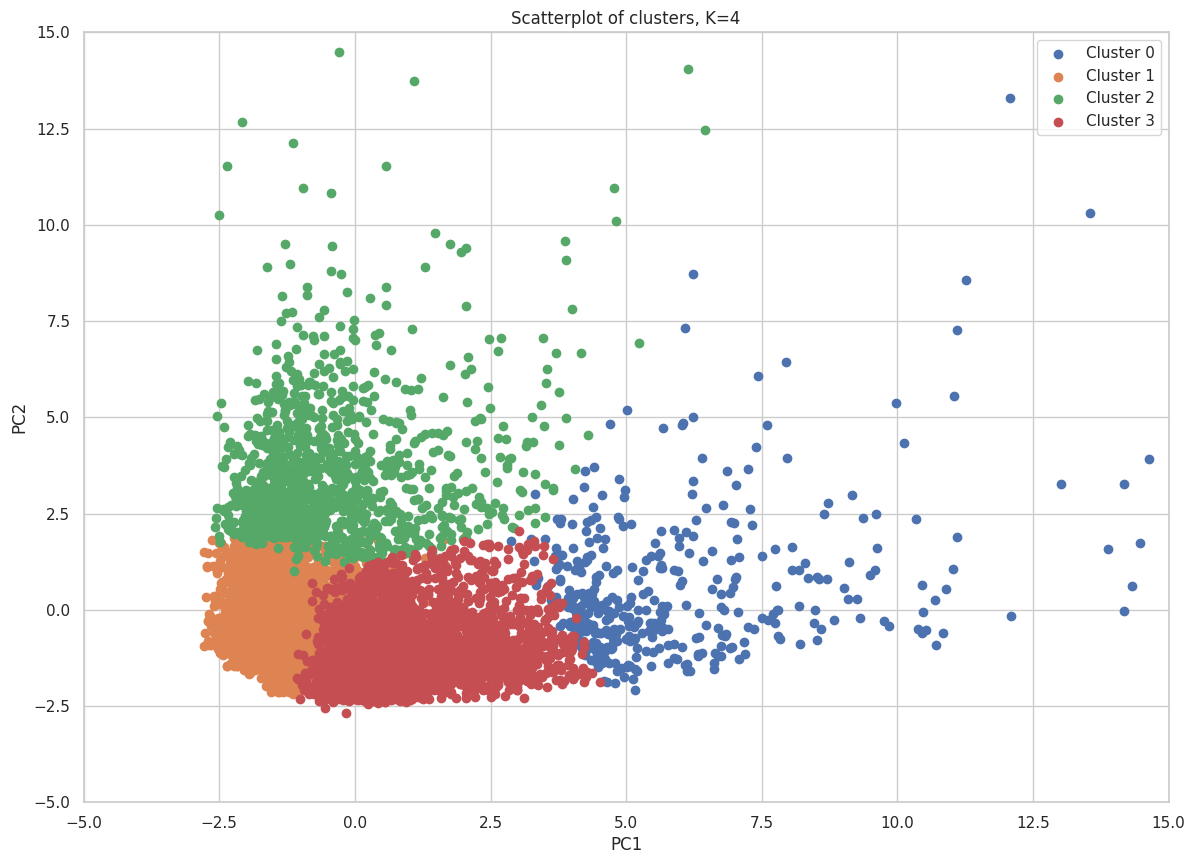

In [32]:
plt.figure(figsize=(14, 10))

clusters_df = pca_df[['PCA1', 'PCA2']]
clusters_df['cluster_label'] = labels
for cluster_name, cluster_data in clusters_df.groupby('cluster_label'):
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster_name}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatterplot of clusters, K=4')
plt.xlim(-5, 15)
plt.ylim(-5, 15)
plt.legend()
plt.show()

# 3.3.1. Biplot

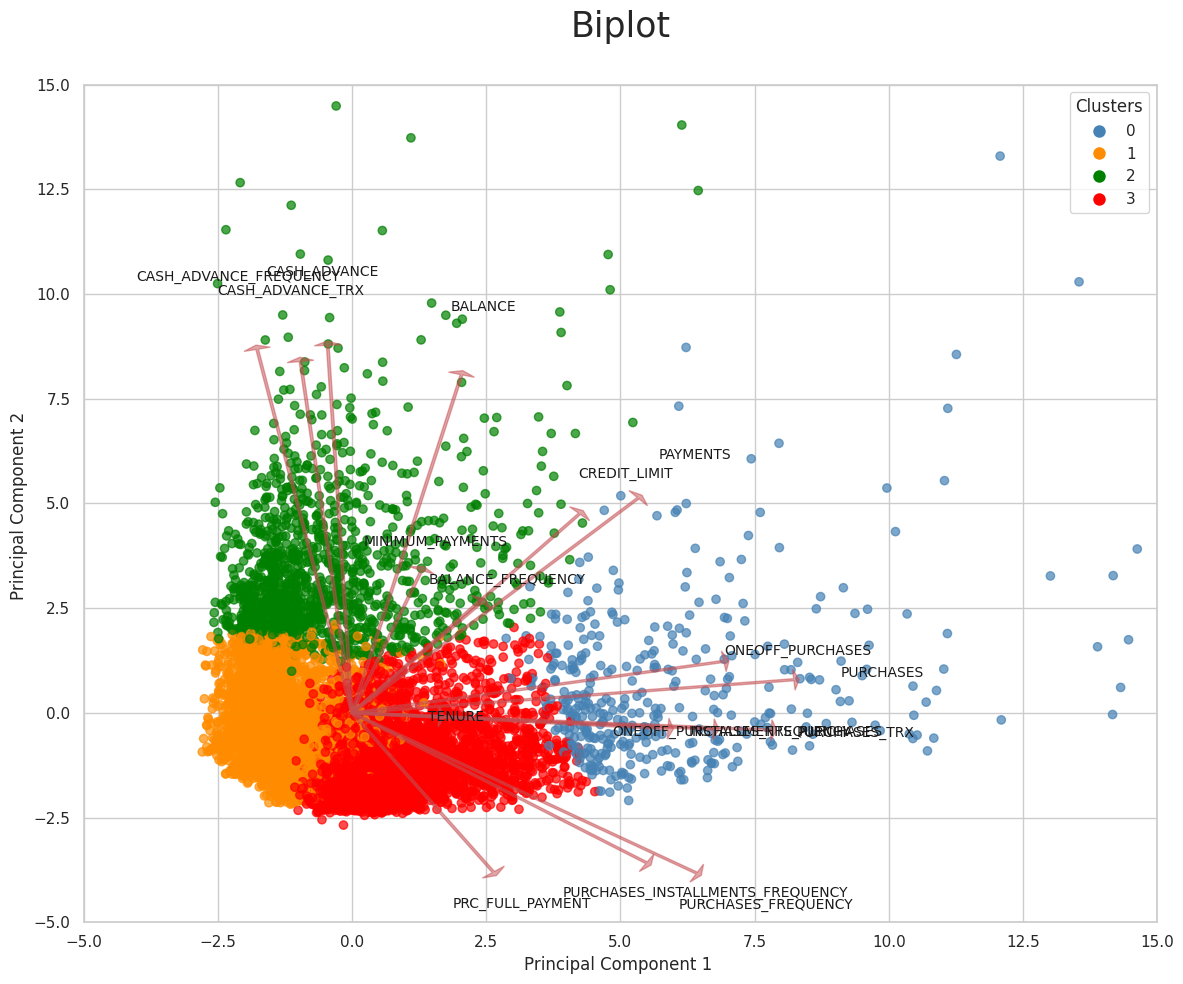

In [33]:
pca_result = pca.fit_transform(df_scaled)

def biplot(score, coeff, labels=None, scaling_factor=1.0):
    plt.figure(figsize=(12, 10))
    coeff = np.transpose(coeff)

    custom_cmap = {0: 'steelblue', 1: 'darkorange', 2: 'green', 3: 'red'}
    cluster_colors = clusters_df['cluster_label'].map(custom_cmap)
    plt.scatter(score[:, 0], score[:, 1], alpha=0.7, c=cluster_colors)

    for i in range(coeff.shape[1]):
        plt.arrow(0, 0, coeff[0, i] * scaling_factor, coeff[1, i] * scaling_factor,
                  color='r', alpha=0.5, head_width=0.5, head_length=0.1,width = 0.05)
        if labels is not None:
            plt.text(coeff[0, i] * scaling_factor * 1.2, coeff[1, i] * scaling_factor * 1.2,
                     labels[i], color='k', ha='center', va='center',fontsize = 10)

    plt.xlabel(f'Principal Component 1 ')
    plt.ylabel(f'Principal Component 2 ')
    plt.title('Biplot\n', fontsize = 25)

    legend_handles = []
    for label, color in custom_cmap.items():
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'{label}', markerfacecolor=color, markersize=10))
    plt.legend(handles=legend_handles, title='Clusters', loc='best')

    plt.xlim(-5, 15)
    plt.ylim(-5, 15)

    img_path = get_img_path("biplot.png")
    plt.tight_layout()

    plt.show()

biplot(pca_result, np.transpose(pca.components_), labels=df.columns, scaling_factor=20.0)

we can see clearly that both the methods from section 3.2 and 3.3 gives us the same result

# 3.4. Hierachial Clustering

## 3.4.1. **Complete Linakge**


complete linkage does not gives good result with standard scaler so we use minmax scaler

Cluster Counts Table:
   Cluster Label  No of Observation
0              0               2924
1              1                 31
2              2               5993
3              3                  1


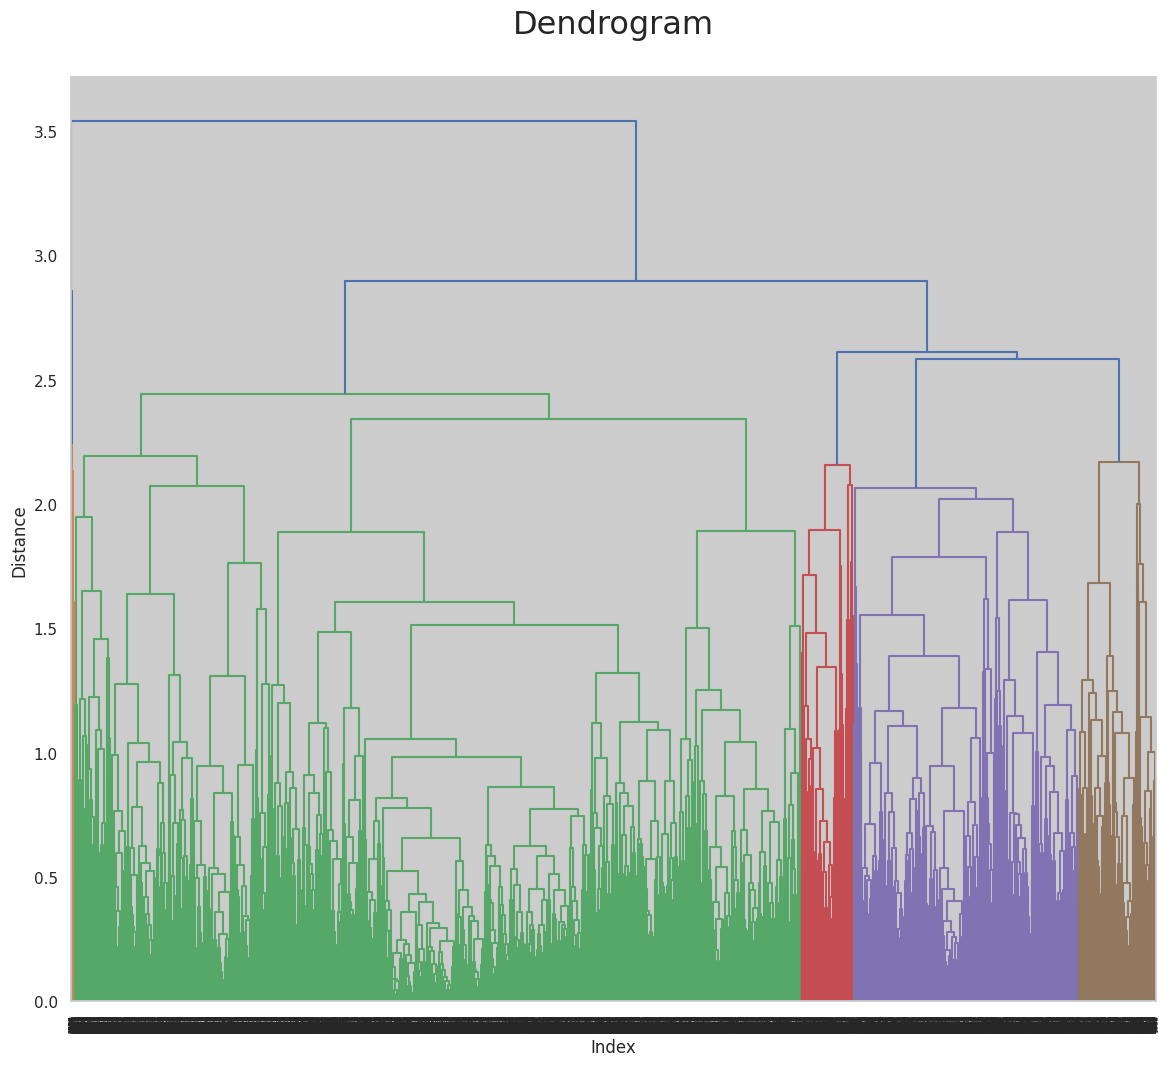

In [141]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Scaling data
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Performing Agglomerative Clustering with complete linkage
model = AgglomerativeClustering(n_clusters=4, linkage='complete')
clusters = model.fit_predict(df_scaled)

# Adding cluster labels to the DataFrame
clusters_df_agg = df_scaled.copy()
clusters_df_agg['cluster_label'] = clusters

# Counting observations per cluster
cluster_counts = clusters_df_agg['cluster_label'].value_counts().reset_index()
cluster_counts.columns = ['Cluster Label', 'No of Observation']
cluster_counts = cluster_counts.sort_values('Cluster Label').reset_index(drop=True)

# Display cluster counts
print("Cluster Counts Table:")
print(cluster_counts)

# Generate dendrogram for complete linkage
linkage_matrix = linkage(df_scaled, method='complete')

plt.figure(figsize=(14, 12))
dendrogram(linkage_matrix)
plt.title('Dendrogram\n', fontsize = 23)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()


In [186]:
from sklearn.metrics import silhouette_score

# Assuming `clusters_df_agg` contains the data with 'cluster_label' assigned from the dendrogram
score = silhouette_score(df_scaled, clusters_df_agg['cluster_label'])
print("Silhouette Score for Complete Linkage Clustering:", score)


Silhouette Score for Complete Linkage Clustering: 0.3337342672461978


- **Cluster Size Imbalance:** Most observations fall into clusters 2 and 0 (5993 and 2924 points, respectively), indicating two dominant clusters.

- **Potential Outliers:** Clusters 1 and 3 are tiny (31 and 1 observation), suggesting they may represent outliers.

- **Cluster Density:** Complete linkage produced compact clusters, with clusters 0 and 2 likely representing denser regions of the data.

**Conclusion:** The uneven cluster sizes and low Silhouette Score imply that complete linkage may not be the best fit if balanced clusters are desired.








# 3.5 GMM

### 3.5.1. n_components = 4

In [154]:
from sklearn.mixture import GaussianMixture

# Define the number of clusters for GMM
n_components = 4 # You can adjust this based on your analysis

# Fit the GMM model
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm_clusters = gmm.fit_predict(df_scaled)

# Adding GMM cluster labels to the DataFrame
clusters_df_gmm = df_scaled.copy()
clusters_df_gmm['gmm_cluster_label'] = gmm_clusters

# Counting observations per GMM cluster
gmm_cluster_counts = clusters_df_gmm['gmm_cluster_label'].value_counts().reset_index()
gmm_cluster_counts.columns = ['GMM Cluster Label', 'No of Observation']
gmm_cluster_counts = gmm_cluster_counts.sort_values('GMM Cluster Label').reset_index(drop=True)

# Display GMM cluster counts
print("GMM Cluster Counts Table:")
print(gmm_cluster_counts)

from sklearn.metrics import silhouette_score

# Calculate the silhouette score for the GMM clustering
silhouette_avg = silhouette_score(df_scaled, gmm_clusters)

print(f"Silhouette Score for GMM clustering: {silhouette_avg}")


GMM Cluster Counts Table:
   GMM Cluster Label  No of Observation
0                  0               2849
1                  1                463
2                  2               2260
3                  3               3377
Silhouette Score for GMM clustering: 0.14869773487737398


The Silhouette Score for GMM clustering is 0.1487, which is close to 0. This low score indicates poor performance of GMM, suggesting that the clusters are not well-defined or distinct.

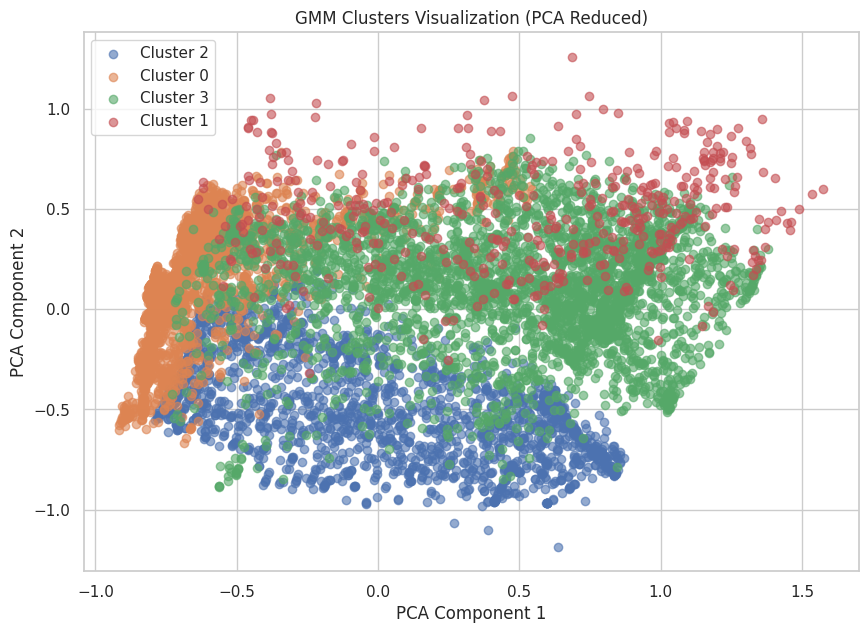

In [155]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=4)
df_pca = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results with the GMM labels
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca['gmm_cluster_label'] = gmm_clusters

# Plotting the clusters
plt.figure(figsize=(10, 7))
for cluster in df_pca['gmm_cluster_label'].unique():
    cluster_data = df_pca[df_pca['gmm_cluster_label'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', alpha=0.6)

plt.title("GMM Clusters Visualization (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


**Significant Overlap:** Clusters, especially 0, 2, and 3, have considerable overlap, indicating poorly defined boundaries.

**Spread of Clusters:** Cluster 3 spans widely, suggesting it captures diverse points, further blurring distinct cluster separations.

**Irregular Shapes:** Clusters do not fully conform to Gaussian (elliptical) shapes, misaligning with GMM’s assumptions.

**Poor Cluster Quality:** The overlap and lack of distinct boundaries explain the low silhouette score, indicating GMM's limitations on this dataset.








### **3.5.2.Hyperparameter Optimization of Gaussian Mixture Model (GMM) Using Optuna for Maximizing Silhouette Score**


In [165]:
import optuna
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

# Define the objective function for Optuna
def objective(trial):
    # Suggest parameters
    n_components = trial.suggest_int('n_components', 2, 10)
    covariance_type = trial.suggest_categorical('covariance_type', ['full', 'tied', 'diag', 'spherical'])
    n_init = trial.suggest_categorical('n_init', [1, 5, 10])

    # Initialize and fit GMM with suggested parameters
    gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(df_scaled)

    # Calculate silhouette score
    score = silhouette_score(df_scaled, labels)

    return score

# Create a study object and optimize it
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # You can increase n_trials for more extensive search

# Retrieve the best parameters and score
best_params = study.best_params
best_score = study.best_value
print("Best parameters found:", best_params)
print("Best silhouette score achieved:", best_score)

# Fit the final GMM model with the best parameters
best_gmm = GaussianMixture(
    n_components=best_params['n_components'],
    covariance_type=best_params['covariance_type'],
    n_init=best_params['n_init'],
    random_state=42
)
best_gmm.fit(df_scaled)


[I 2024-11-11 07:37:17,588] A new study created in memory with name: no-name-74df003a-a398-44d7-b44c-eac533deb786
[I 2024-11-11 07:38:43,150] Trial 0 finished with value: 0.0635067304413128 and parameters: {'n_components': 9, 'covariance_type': 'full', 'n_init': 10}. Best is trial 0 with value: 0.0635067304413128.
[I 2024-11-11 07:38:52,249] Trial 1 finished with value: 0.05110652550711012 and parameters: {'n_components': 9, 'covariance_type': 'diag', 'n_init': 10}. Best is trial 0 with value: 0.0635067304413128.
[I 2024-11-11 07:38:57,490] Trial 2 finished with value: 0.18585551592829894 and parameters: {'n_components': 10, 'covariance_type': 'spherical', 'n_init': 10}. Best is trial 2 with value: 0.18585551592829894.
[I 2024-11-11 07:38:59,716] Trial 3 finished with value: 0.1381982456876413 and parameters: {'n_components': 4, 'covariance_type': 'diag', 'n_init': 5}. Best is trial 2 with value: 0.18585551592829894.
[I 2024-11-11 07:39:02,673] Trial 4 finished with value: 0.2668672987

Best parameters found: {'n_components': 2, 'covariance_type': 'tied', 'n_init': 1}
Best silhouette score achieved: 0.3361245461192623


GaussianMixture(covariance_type='tied', n_components=2, random_state=42)

### **3.5.3. GMM with best Parameters**

Silhouette Score for optimized GMM clustering: 0.3361245461192623


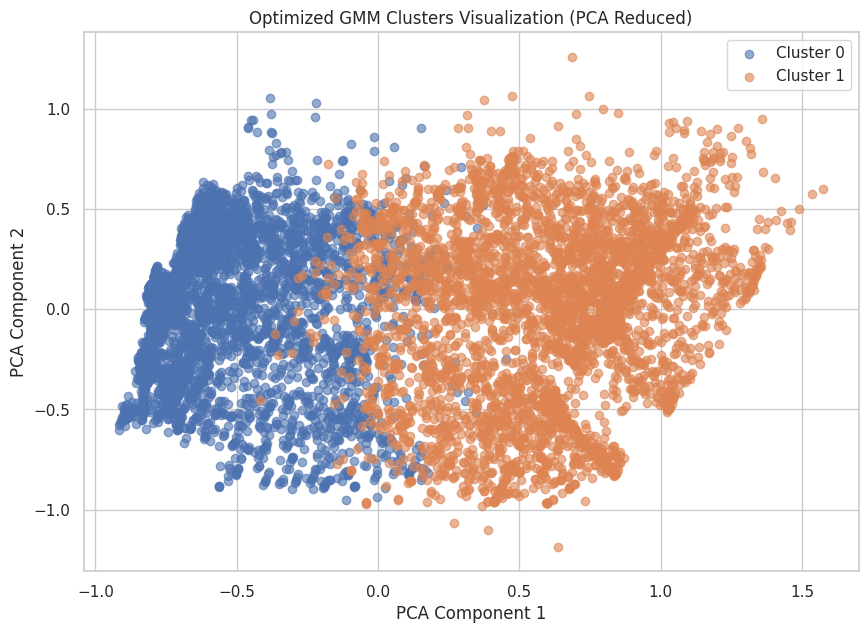

In [166]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Initialize Gaussian Mixture Model with the best parameters
best_gmm = GaussianMixture(covariance_type='tied', n_components=2, random_state=42)
gmm_clusters = best_gmm.fit_predict(df_scaled)

# Calculate silhouette score with the best parameters
silhouette_avg = silhouette_score(df_scaled, gmm_clusters)
print(f"Silhouette Score for optimized GMM clustering: {silhouette_avg}")

# Optional: Add cluster labels to the DataFrame for further analysis
clusters_df = df_scaled.copy()
clusters_df['gmm_cluster_label'] = gmm_clusters

# Visualize the clusters using PCA for 2D projection
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Convert PCA result to DataFrame
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca['gmm_cluster_label'] = gmm_clusters

# Plot the clusters
plt.figure(figsize=(10, 7))
for cluster in df_pca['gmm_cluster_label'].unique():
    cluster_data = df_pca[df_pca['gmm_cluster_label'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', alpha=0.6)

plt.title("Optimized GMM Clusters Visualization (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


Clusters are better separated, though some overlap remains, particularly in the center.

The optimized silhouette score of 0.336 indicates moderate improvement in clustering quality.

lets check assumptions of GMM it might possible that assumptions not satisfied leads to poor performance









## **3.5.4 Checking Assumption for GMM**

### 1. Gaussian Distribution of Each Cluster

In [179]:
from scipy.stats import shapiro
import pandas as pd

# Perform Shapiro-Wilk test for each feature in each cluster
gmm_clusters = best_gmm.fit_predict(df_scaled)  # Assuming best_gmm and df_scaled are defined
clusters_df = df_scaled.copy()
clusters_df['cluster'] = gmm_clusters

# Store Shapiro-Wilk test results
results = []

for cluster in clusters_df['cluster'].unique():
    cluster_data = clusters_df[clusters_df['cluster'] == cluster].drop(columns='cluster')
    normal_features = []
    print(f"\nCluster {cluster} - Normally Distributed Features:")
    for col in cluster_data.columns:
        stat, p_value = shapiro(cluster_data[col])
        if p_value >= 0.05:
            normal_features.append((col, p_value))

    # Check if there are normally distributed features
    if normal_features:
        for feature, p_value in normal_features:
            print(f"Feature '{feature}' - p-value: {p_value} (Likely Normally Distributed)")
    else:
        print("No features follow a normal distribution")



Cluster 0 - Normally Distributed Features:
Feature 'Cluster' - p-value: 1.0 (Likely Normally Distributed)
Feature 'Cluster_Label' - p-value: 1.0 (Likely Normally Distributed)

Cluster 1 - Normally Distributed Features:
No features follow a normal distribution


<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

### 2. Independence of Features within Each Cluster

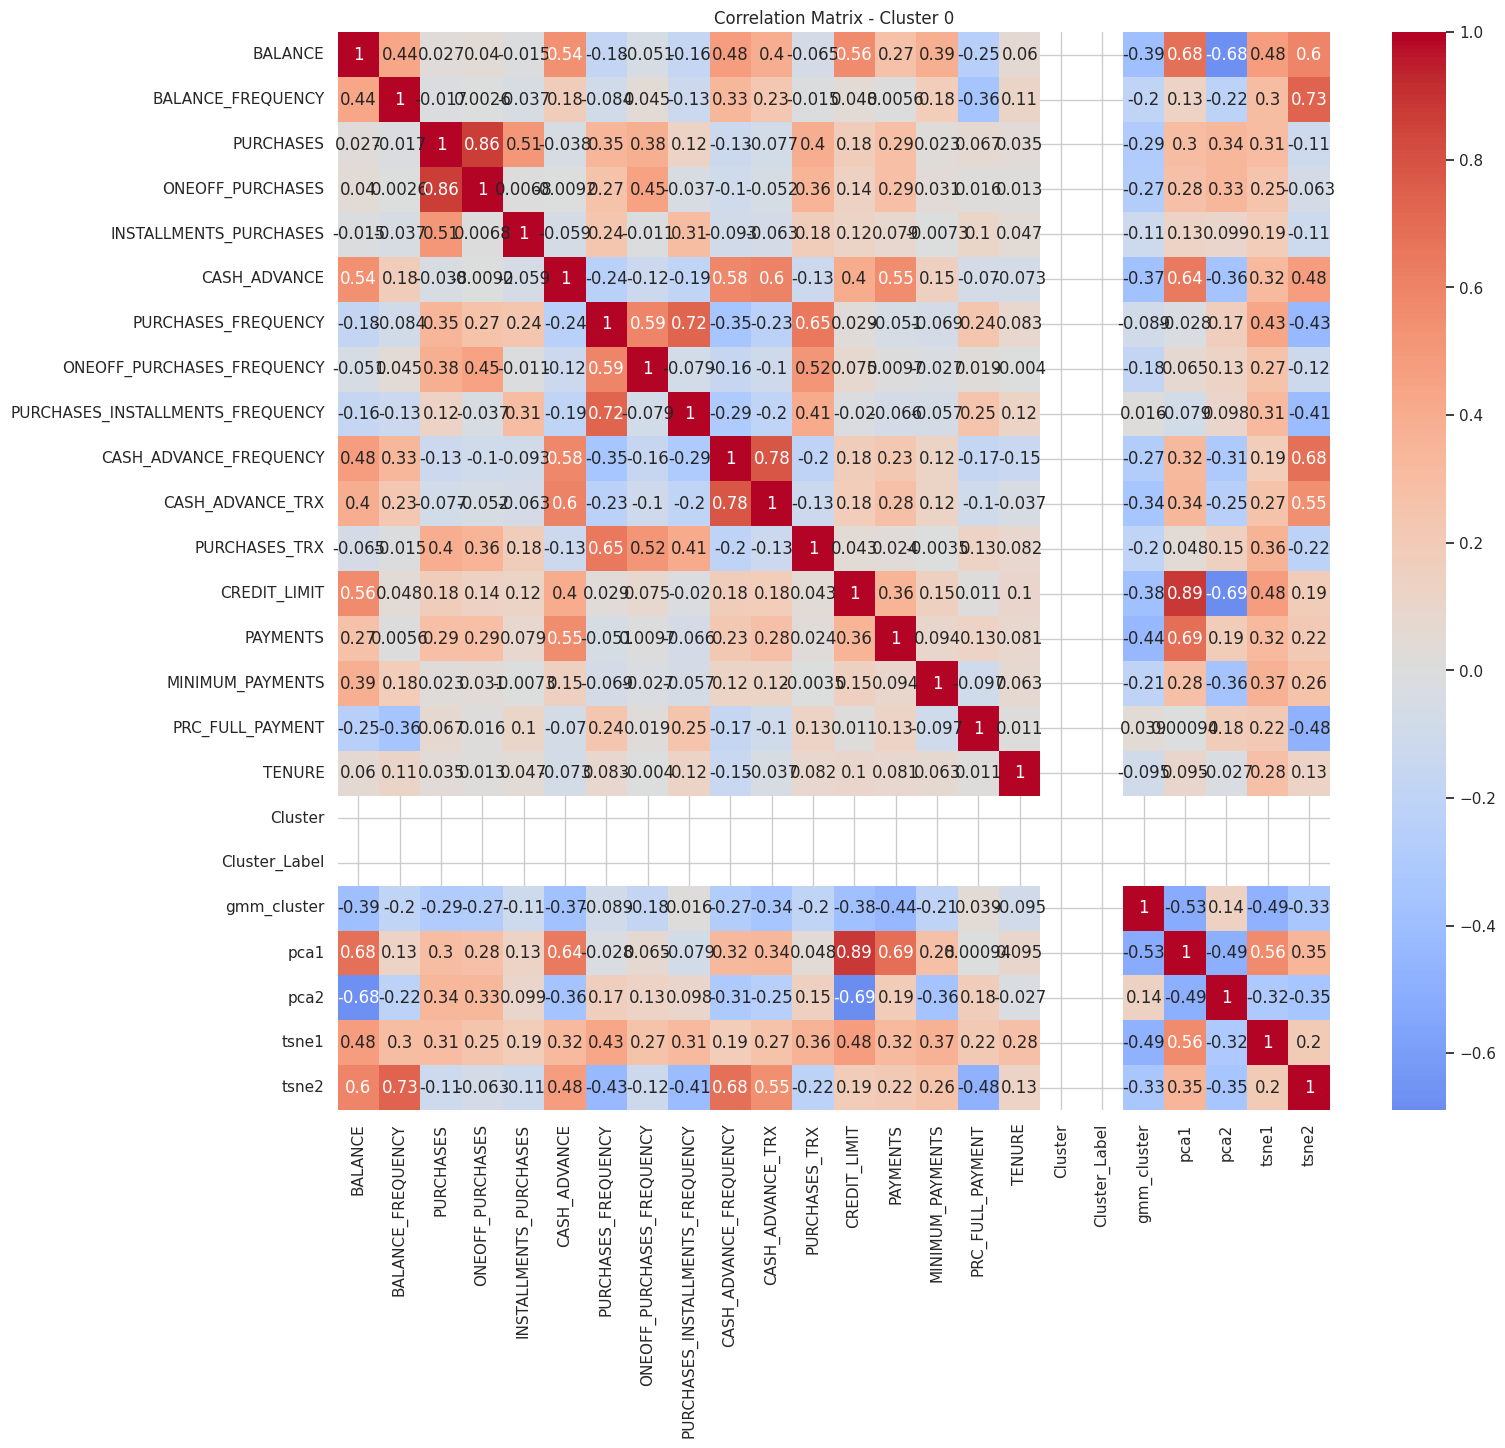

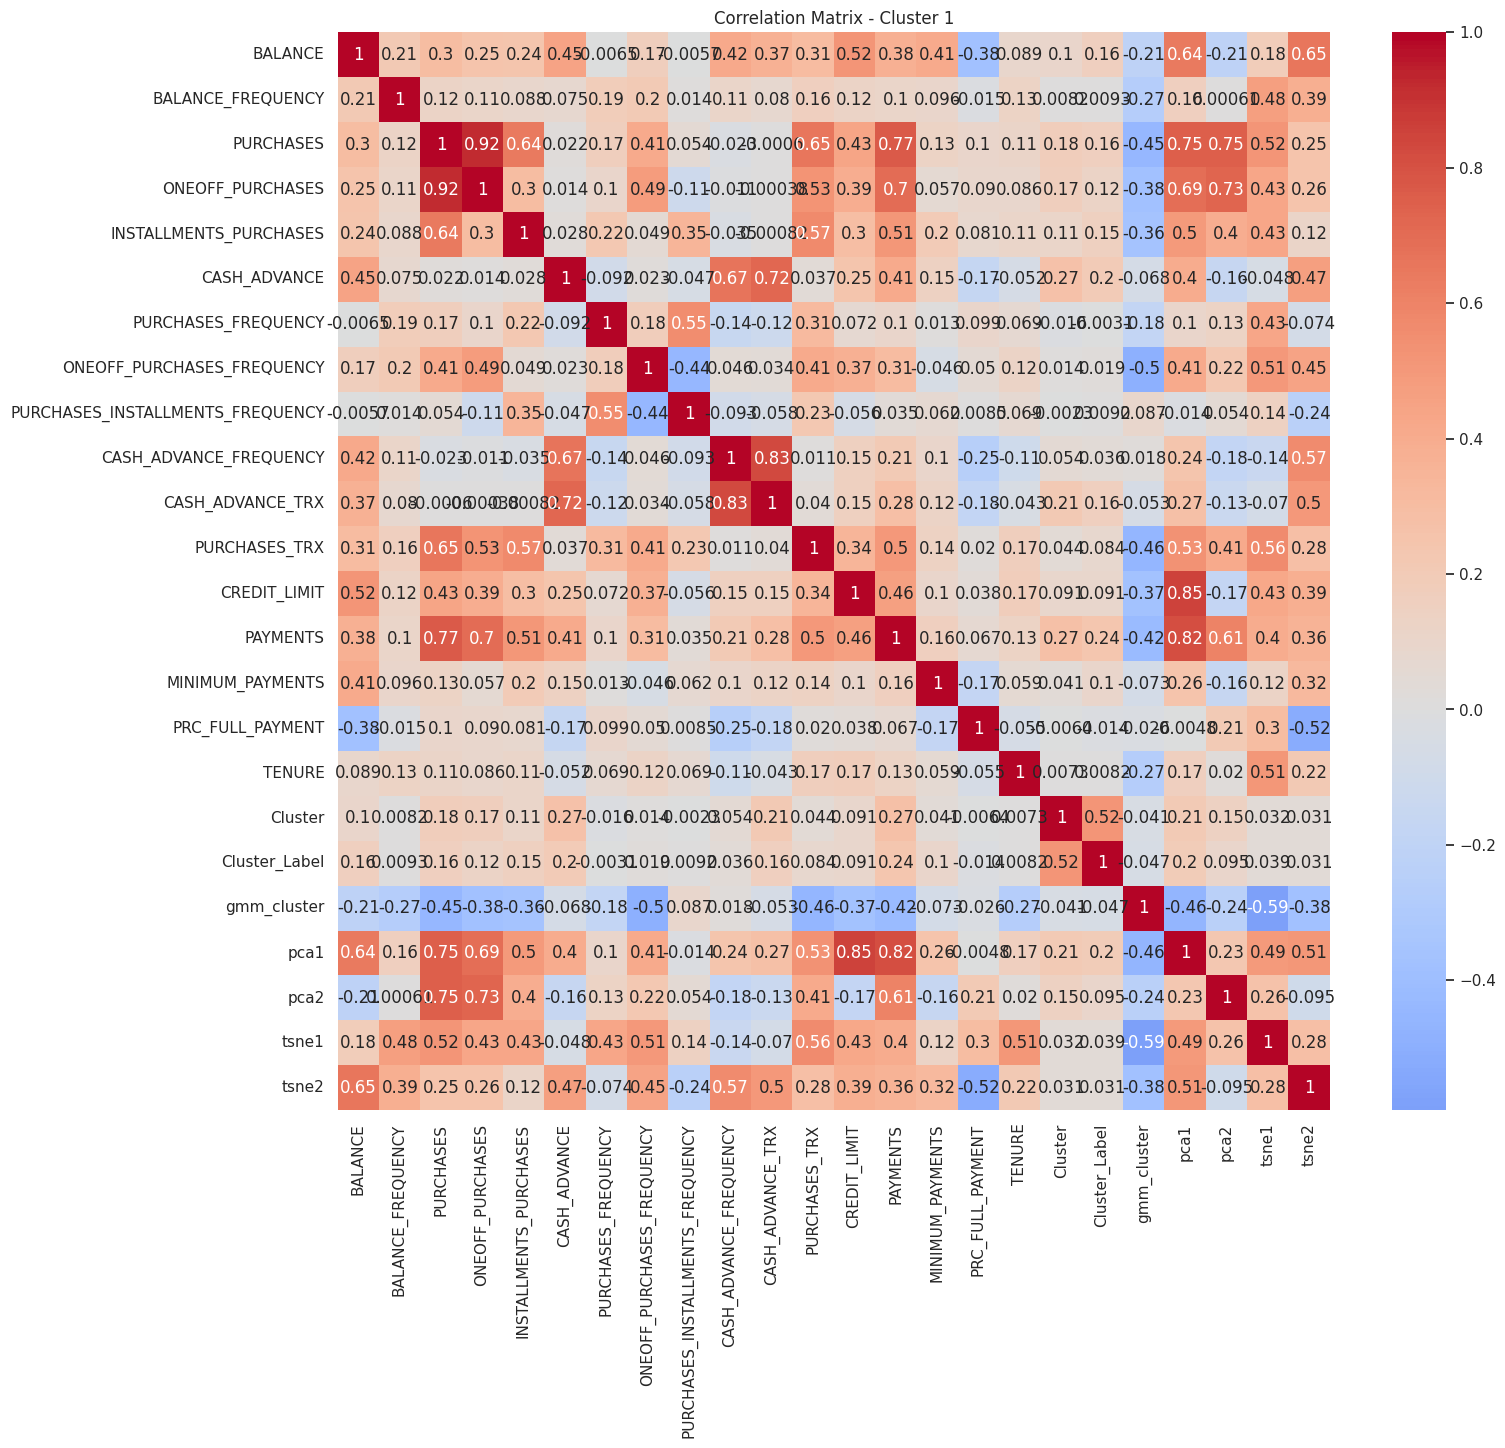

In [183]:
import seaborn as sns

for cluster in clusters_df['cluster'].unique():
    cluster_data = clusters_df[clusters_df['cluster'] == cluster].drop(columns='cluster')
    plt.figure(figsize=(16, 14))
    sns.heatmap(cluster_data.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Matrix - Cluster {cluster}')
    plt.show()


The correlation matrices for both clusters show that many features are not independent within each cluster. This is especially notable for features directly related to similar aspects (e.g., cash advances, payments, and purchases), which tend to be correlated due to their inherent relationships in the data.

Given this, the independence assumption in GMM is not fully met, especially if you are using spherical or diag covariance types, which assume uncorrelated features within each cluster.








### 3. Cluster Shape and Spread (Covariance Structure)

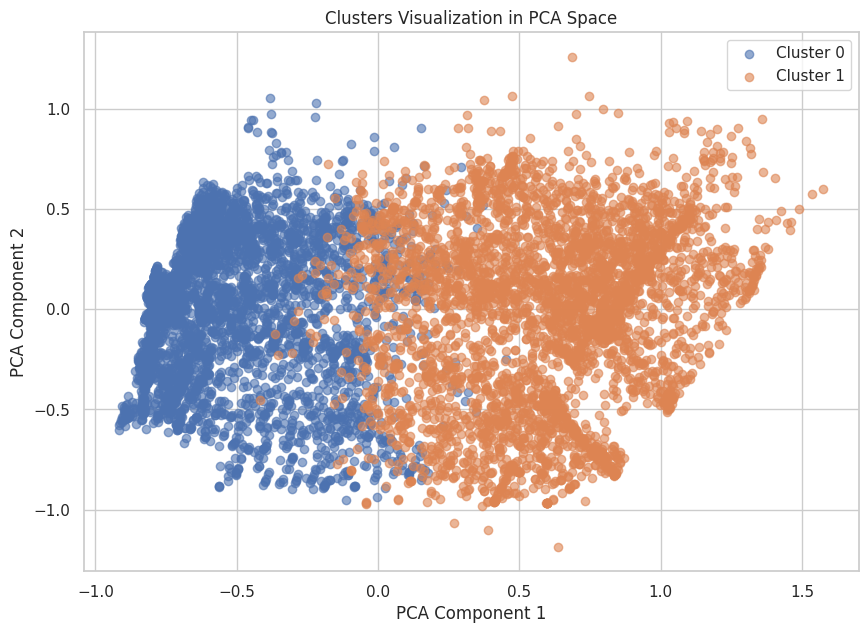

In [184]:
from sklearn.decomposition import PCA

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca['cluster'] = gmm_clusters

# Plot clusters in PCA space
plt.figure(figsize=(10, 7))
for cluster in df_pca['cluster'].unique():
    cluster_data = df_pca[df_pca['cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', alpha=0.6)

plt.title("Clusters Visualization in PCA Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


The clusters have an elliptical shape, which is good, but the overlap indicates that the clusters aren’t as well-defined and separate as GMM ideally assumes. This could impact the effectiveness of the model, especially if the goal is to have distinct, non-overlapping clusters.

### 4. Cluster Weights

In [185]:
# Calculate the proportion of points in each cluster
cluster_proportions = clusters_df['cluster'].value_counts(normalize=True)

# Compare with the GMM's estimated weights
print("Cluster Proportions based on Data:")
print(cluster_proportions)

print("\nGMM Estimated Weights:")
print(best_gmm.weights_)


Cluster Proportions based on Data:
cluster
0    0.528774
1    0.471226
Name: proportion, dtype: float64

GMM Estimated Weights:
[0.52957806 0.47042194]


The estimated weights and actual proportions align closely. This suggests that GMM is effectively modeling the underlying distribution in terms of cluster sizes

**Reason for Poor performance of GMM:**

The poor performance of GMM, reflected in the low silhouette score, is likely due to the fact that not all of its assumptions are fully satisfied in this dataset. When key assumptions—such as normal distribution of each cluster, feature independence, and clear separation of clusters—are not met, the model may struggle to accurately capture the data structure, leading to suboptimal clustering results.


# **Final Result**

After applying and evaluating K-Means, Gaussian Mixture Model (GMM), and Hierarchical Clustering on the dataset, K-Means emerged as the most effective clustering method, providing the highest silhouette score and well-separated clusters. K-Means achieved optimal results with 4 clusters, which aligned well with the natural grouping in the data, as confirmed by both visualizations and cluster compactness. Unlike GMM and Hierarchical Clustering, which showed considerable overlap and imbalanced cluster sizes, K-Means created distinct and balanced clusters, demonstrating its robustness and suitability for this dataset. Its efficiency, simplicity, and ability to form compact clusters with clear boundaries make K-Means the best choice for this analysis.